# Visualization

`.x.plot()` picks a plot type from the data's dimensions: a map for anything with
lat/lon, `ncol`, or `nlat`/`nlon`; a filled contour section for other 2-D data; a
line for 1-D.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
ts_path = os.path.join(
    case_dir, 'atm', 'proc', 'tseries', 'month_1',
    f'{casename}.cam.h0.TS.000101-000512.nc',
)
ssh_path = os.path.join(
    case_dir, 'ocn', 'proc', 'tseries', 'month_1',
    f'{casename}.pop.h.SSH.000101-000512.nc',
)

ds = x4c.open_dataset(ts_path, comp='atm', grid='ne16np4', vn='TS', shift_time=True)
da = ds.x.da.x.annualize().mean('time')

ds_ssh = x4c.open_dataset(ssh_path, comp='ocn', grid='g16', vn='SSH', shift_time=True)

<conda-env>/lib/python3.13/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'gmt' loading failed:
Error loading GMT shared library at 'libgmt.so'.
libgmt.so: cannot open shared object file: No such file or directory
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


## Model coastlines for a paleo run

This is a Miocene simulation, so modern coastlines are simply wrong. The trick is to
pass a **sea-surface variable** as `ssv`: `x4c` contours where that field turns to
NaN, which is exactly the model's own land-sea boundary.

`ssv` has to be on a regular lat/lon grid, so regrid it first.

In [3]:
ssv = ds_ssh.x.regrid().x.da.mean('time')
print('ssv:', dict(ssv.sizes))

ssv: {'lat': 180, 'lon': 360}


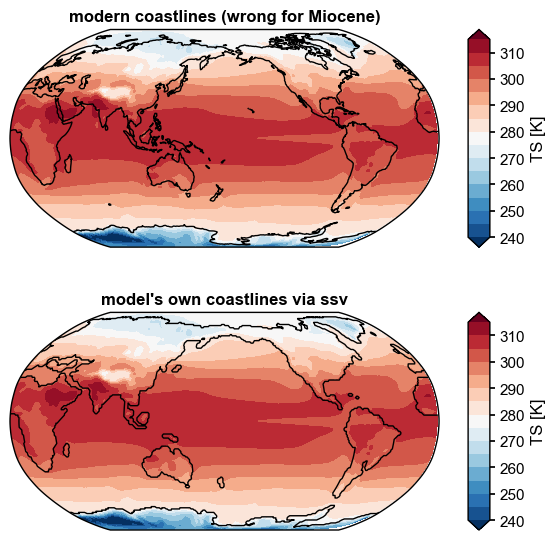

In [4]:
ax_loc = {'a': (0, 0), 'b': (1, 0)}
projs = {k: 'Robinson' for k in ax_loc}
projs_kws = {k: {'central_longitude': 180} for k in ax_loc}
fig, axd = x4c.subplots(2, 1, ax_loc=ax_loc, projs=projs, projs_kws=projs_kws,
                        figsize=(7.5, 6.5), hspace=0.3)

levels = np.linspace(240, 315, 16)
da.x.plot(ax=axd['a'], levels=levels, title='modern coastlines (wrong for Miocene)')
da.x.plot(ax=axd['b'], levels=levels, ssv=ssv, title="model's own coastlines via ssv")
x4c.showfig(fig)

## Projections and cropping

`projection` takes any Cartopy projection class name; `latlon_range` crops.

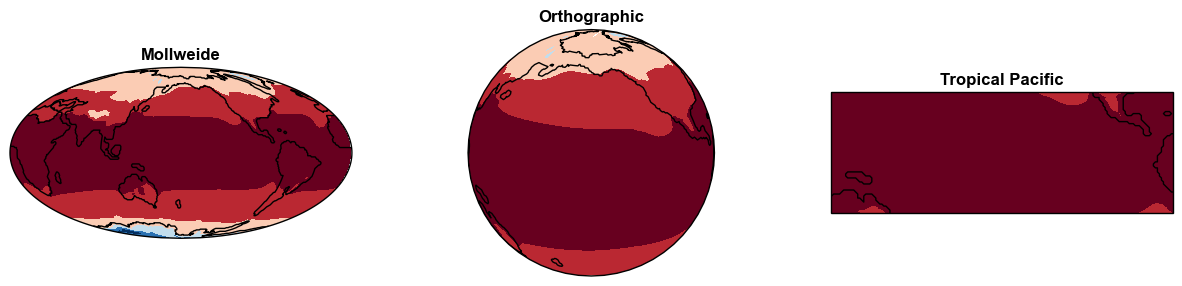

In [5]:
ax_loc = {'a': (0, 0), 'b': (0, 1), 'c': (0, 2)}
projs = {'a': 'Mollweide', 'b': 'Orthographic', 'c': 'PlateCarree'}
projs_kws = {'a': {'central_longitude': 180},
             'b': {'central_longitude': 200, 'central_latitude': 20},
             'c': {'central_longitude': 180}}
fig, axd = x4c.subplots(1, 3, ax_loc=ax_loc, projs=projs, projs_kws=projs_kws,
                        figsize=(15, 3.2), wspace=0.2)

da.x.plot(ax=axd['a'], ssv=ssv, title='Mollweide', add_colorbar=False)
da.x.plot(ax=axd['b'], ssv=ssv, title='Orthographic', add_colorbar=False)
da.x.plot(ax=axd['c'], ssv=ssv, title='Tropical Pacific',
          latlon_range=(-30, 30, 120, 290), add_colorbar=False)
x4c.showfig(fig)

## Contour levels, colormaps, gridlines

The colormap is inferred from the variable's `long_name` when you do not set one —
temperature gets a diverging map, precipitation gets `BrBG`, and so on. Anything not
recognised by `.x.plot()` is forwarded to xarray's `contourf`.

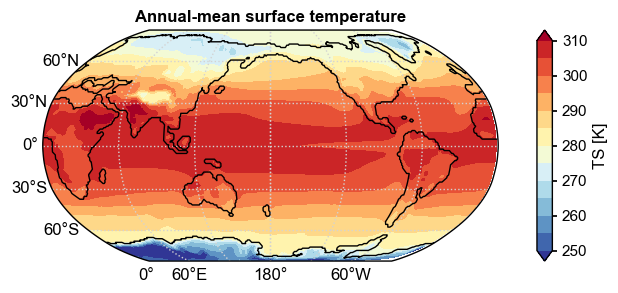

In [6]:
fig, ax = da.x.plot(
    ssv=ssv,
    cmap='RdYlBu_r',
    levels=np.linspace(250, 310, 13),
    extend='both',
    add_gridlines=True,
    gridline_style=':',
    title='Annual-mean surface temperature',
    cbar_kwargs={'label': 'TS [K]', 'orientation': 'vertical', 'aspect': 15},
)
x4c.showfig(fig)

## Vertical sections

A 2-D field that is not a map is drawn as a filled contour section. The meridional
overturning circulation is the natural example: it comes out of POP already as
latitude by depth.

In [7]:
moc_path = os.path.join(
    case_dir, 'ocn', 'proc', 'tseries', 'month_1',
    f'{casename}.pop.h.MOC.000101-000512.nc',
)
ds_moc = x4c.open_dataset(moc_path, comp='ocn', grid='g16', vn='MOC', shift_time=True)

moc = ds_moc.x.da.isel(transport_reg=0, moc_comp=0).mean('time')
moc = moc.rename({'moc_z': 'z_t', 'lat_aux_grid': 'lat'})
moc['z_t'] = moc['z_t'] / 1e5          # cm -> km
moc['z_t'].attrs['units'] = 'km'
moc.attrs['long_name'] = 'Meridional Ocean Circulation'
print(dict(moc.sizes))

{'z_t': 61, 'lat': 91}


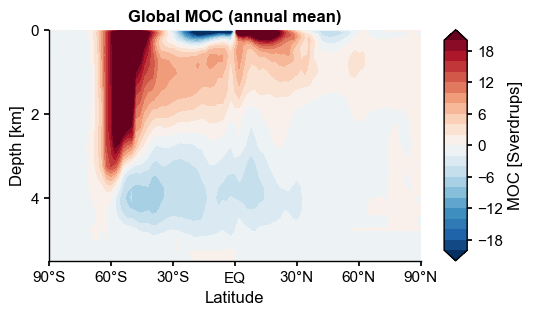

In [8]:
fig, ax = moc.x.plot(levels=np.linspace(-20, 20, 21),
                     title='Global MOC (annual mean)')
x4c.showfig(fig)

## Timeseries

1-D data takes the line branch.

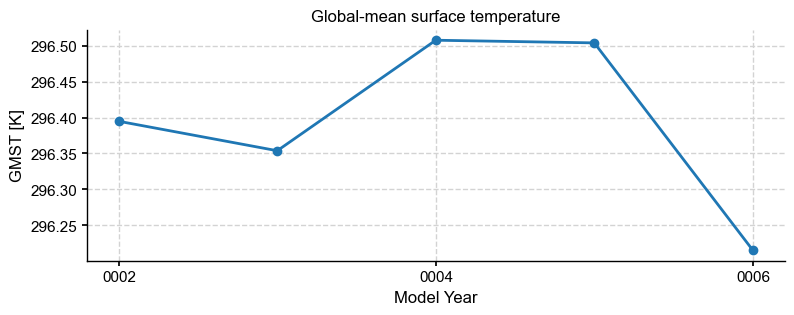

In [9]:
gmst = ds.x.da.x.annualize().x.gm
fig, ax = gmst.x.plot(figsize=(9, 3), marker='o')
ax.set(title='Global-mean surface temperature', ylabel='GMST [K]')
x4c.showfig(fig)

## Styles and saving

`x4c.set_style()` accepts `journal`, `nature`, `agu`, `web`, `presentation`, `dark`
and `minimal`, with `_grid`/`_nogrid` and `_spines`/`_nospines` modifiers.

`x4c.savefig()` creates missing directories and trims whitespace. If the path has no
recognised extension it appends `.pdf`.

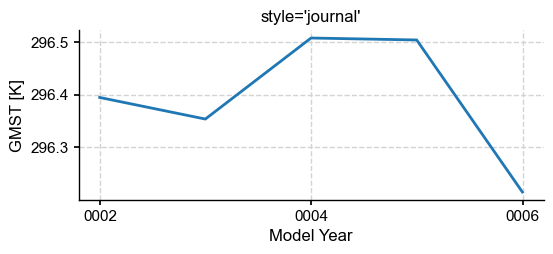

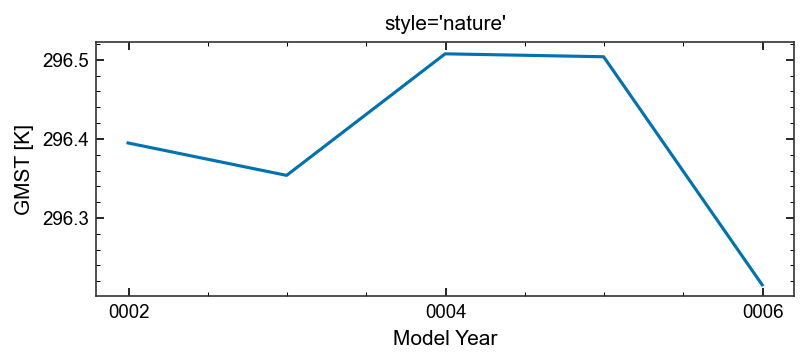

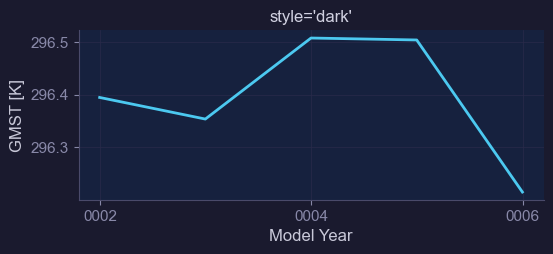

In [10]:
for style in ['journal', 'nature', 'dark']:
    x4c.set_style(style)
    fig, ax = gmst.x.plot(figsize=(6, 2.2))
    ax.set(title=f"style='{style}'", ylabel='GMST [K]')
    x4c.showfig(fig)

x4c.set_style('journal')  # restore